In [44]:
import sys
sys.path.append("..")
%run "../moduli.py"

Funzione teorica
$$\Delta\phi(\omega) = \arctan(Q (\frac{\Omega}{\omega} - \frac{\omega}{\Omega}))$$

con $ \omega = 2 \pi f$.

In [45]:
def modello(par, f): # Capi di C
    Omega, Q, x_off, y_off = par
    omega = 2 * np.pi * (f + x_off)
    #omega = f + x_off
    return np.arctan(
        (1 / Q) * (1 / ((Omega / omega) - (omega / Omega)))
    ) + y_off

param_labels = ["\\Omega", "Q", "f_{off}", "\\Phi_{off}"]

#beta0 = [233*10**4, 3, 1, 1]
beta0 = [2*np.pi*70000, 6, 1, 1]

print(beta0[0])

439822.971502571


In [46]:
def modello(par, f): # Capi di R
    Omega, Q, x_off, y_off = par
    omega = 2 * np.pi * (f + x_off)
    #omega = f + x_off
    return np.arctan(
        -Q * ((Omega / omega) - (omega / Omega))
    ) + y_off

param_labels = ["\\Omega", "Q", "f_{off}", "\\Phi_{off}"]

#beta0 = [233*10**4, 3, 1, 1]
beta0 = [2*np.pi*70000, 6, 1, 1]

print(beta0[0])

439822.971502571


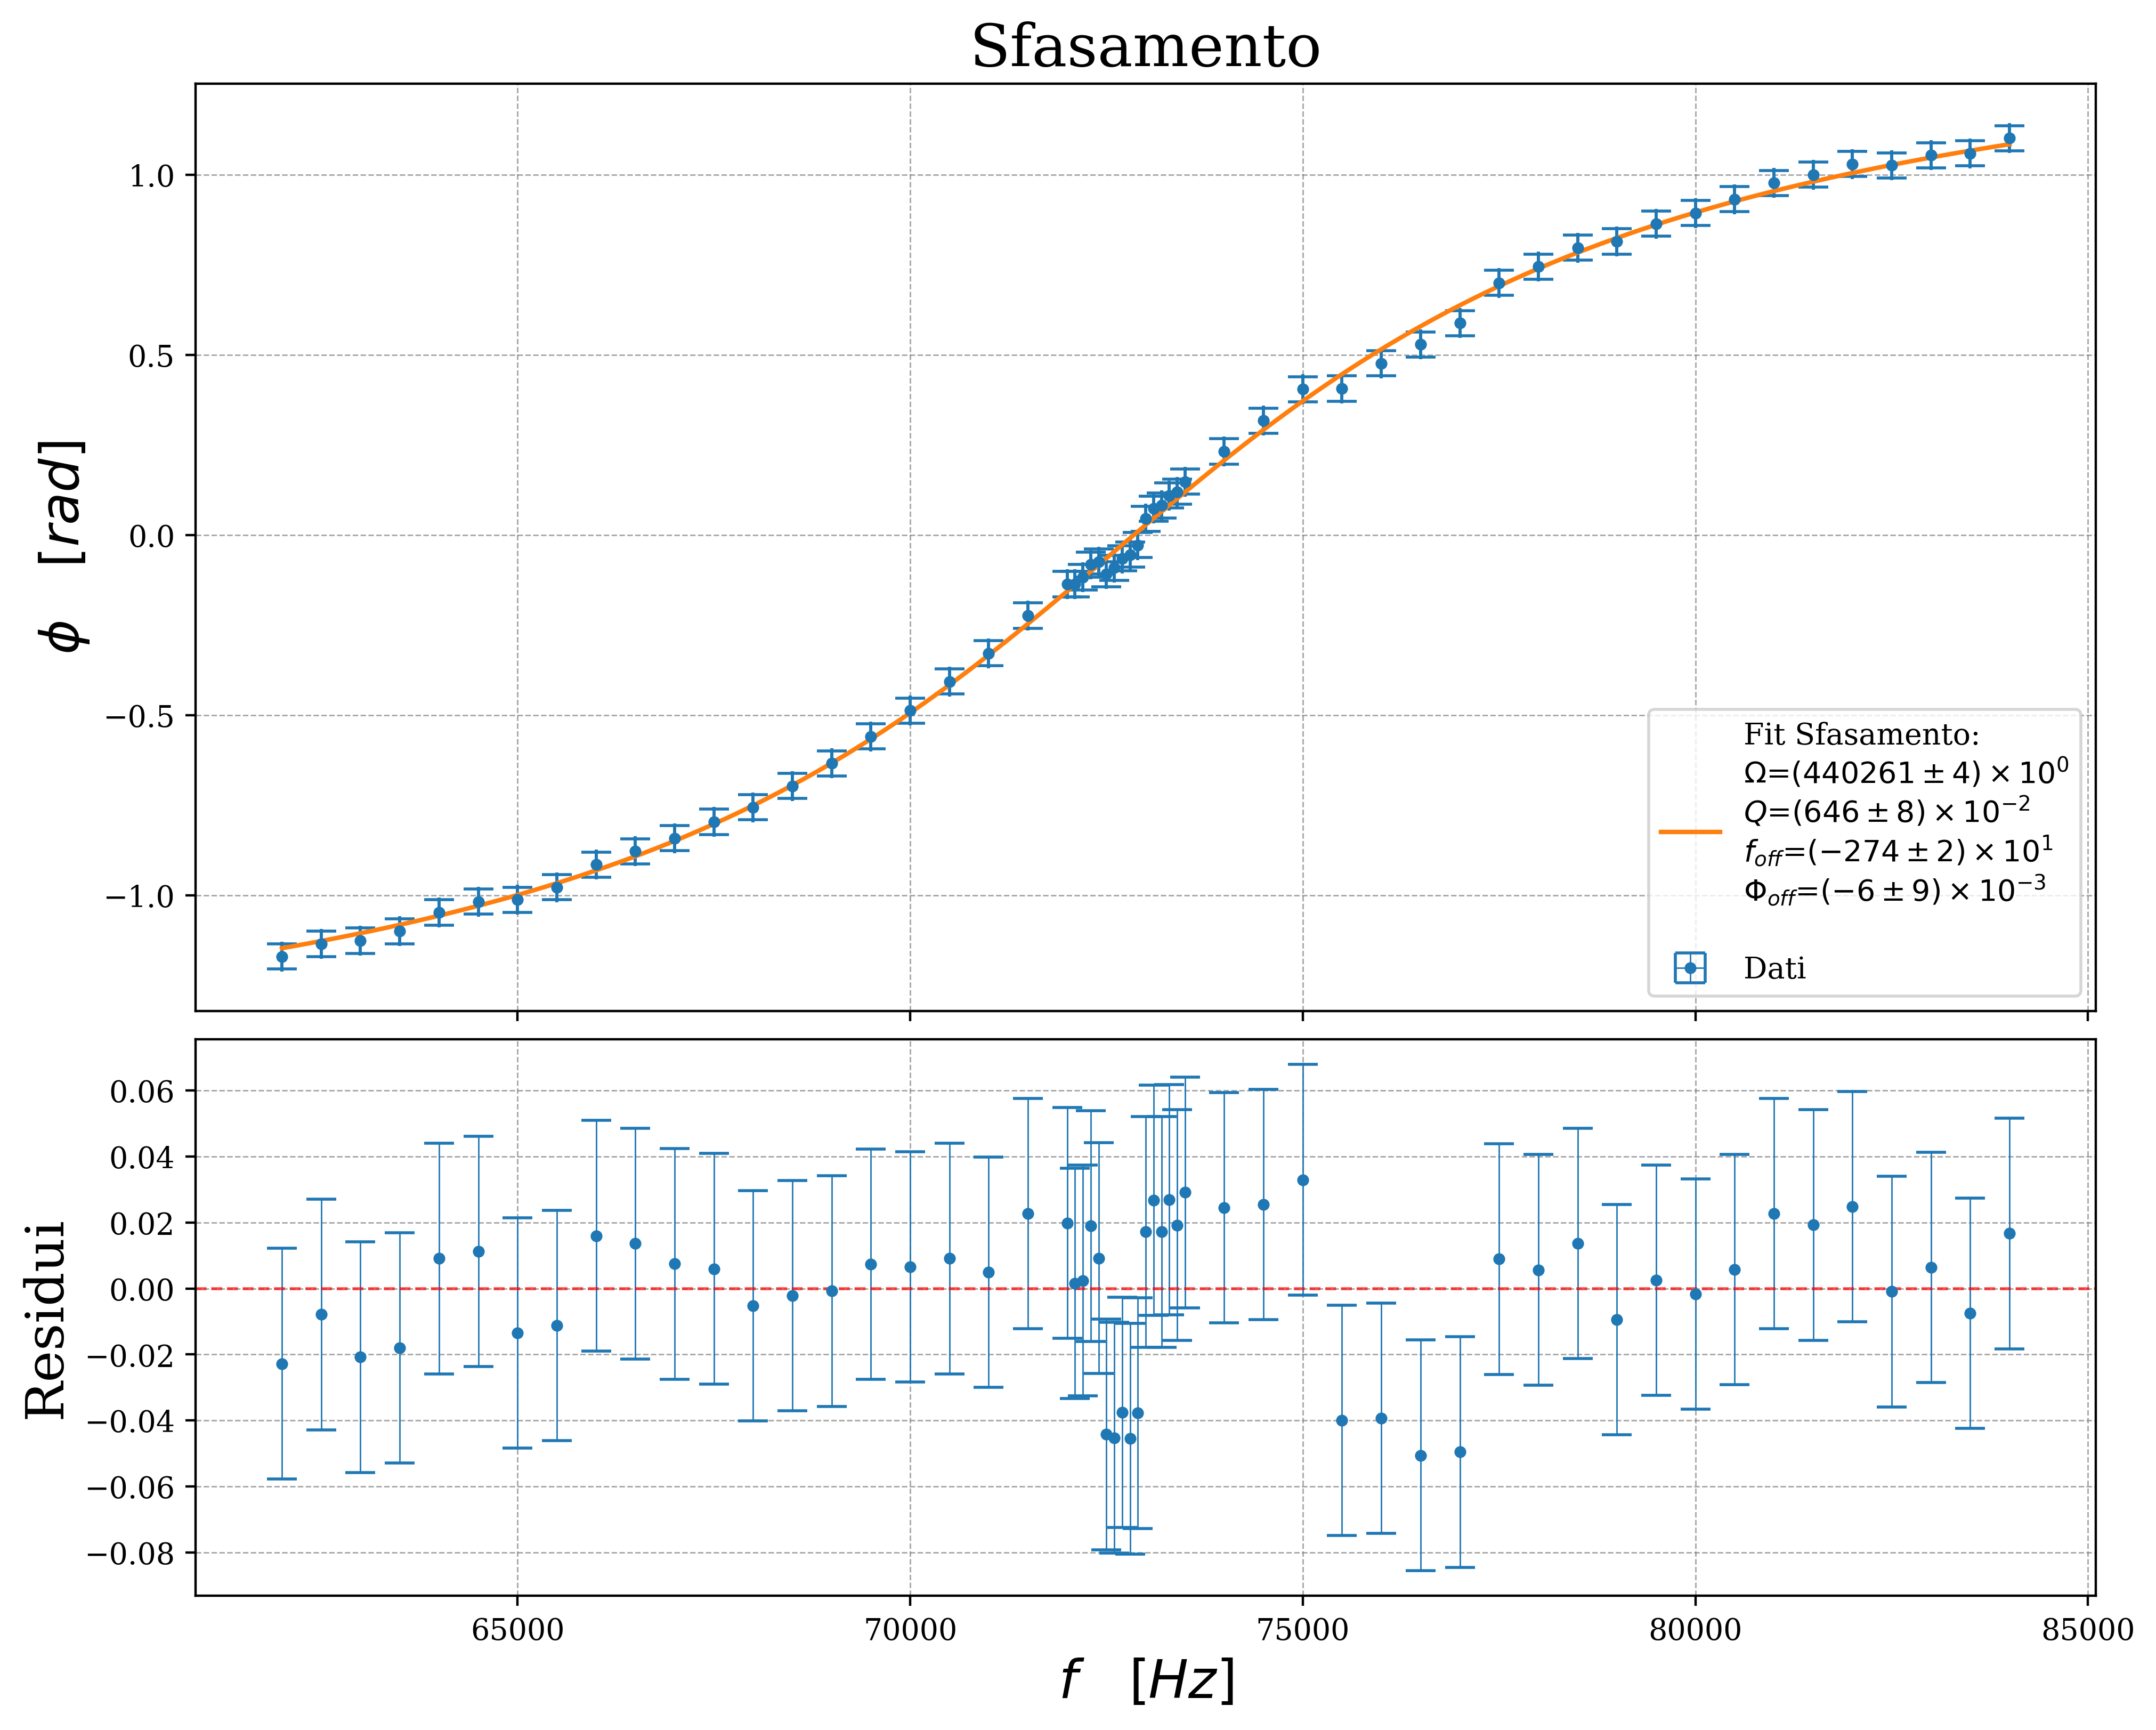

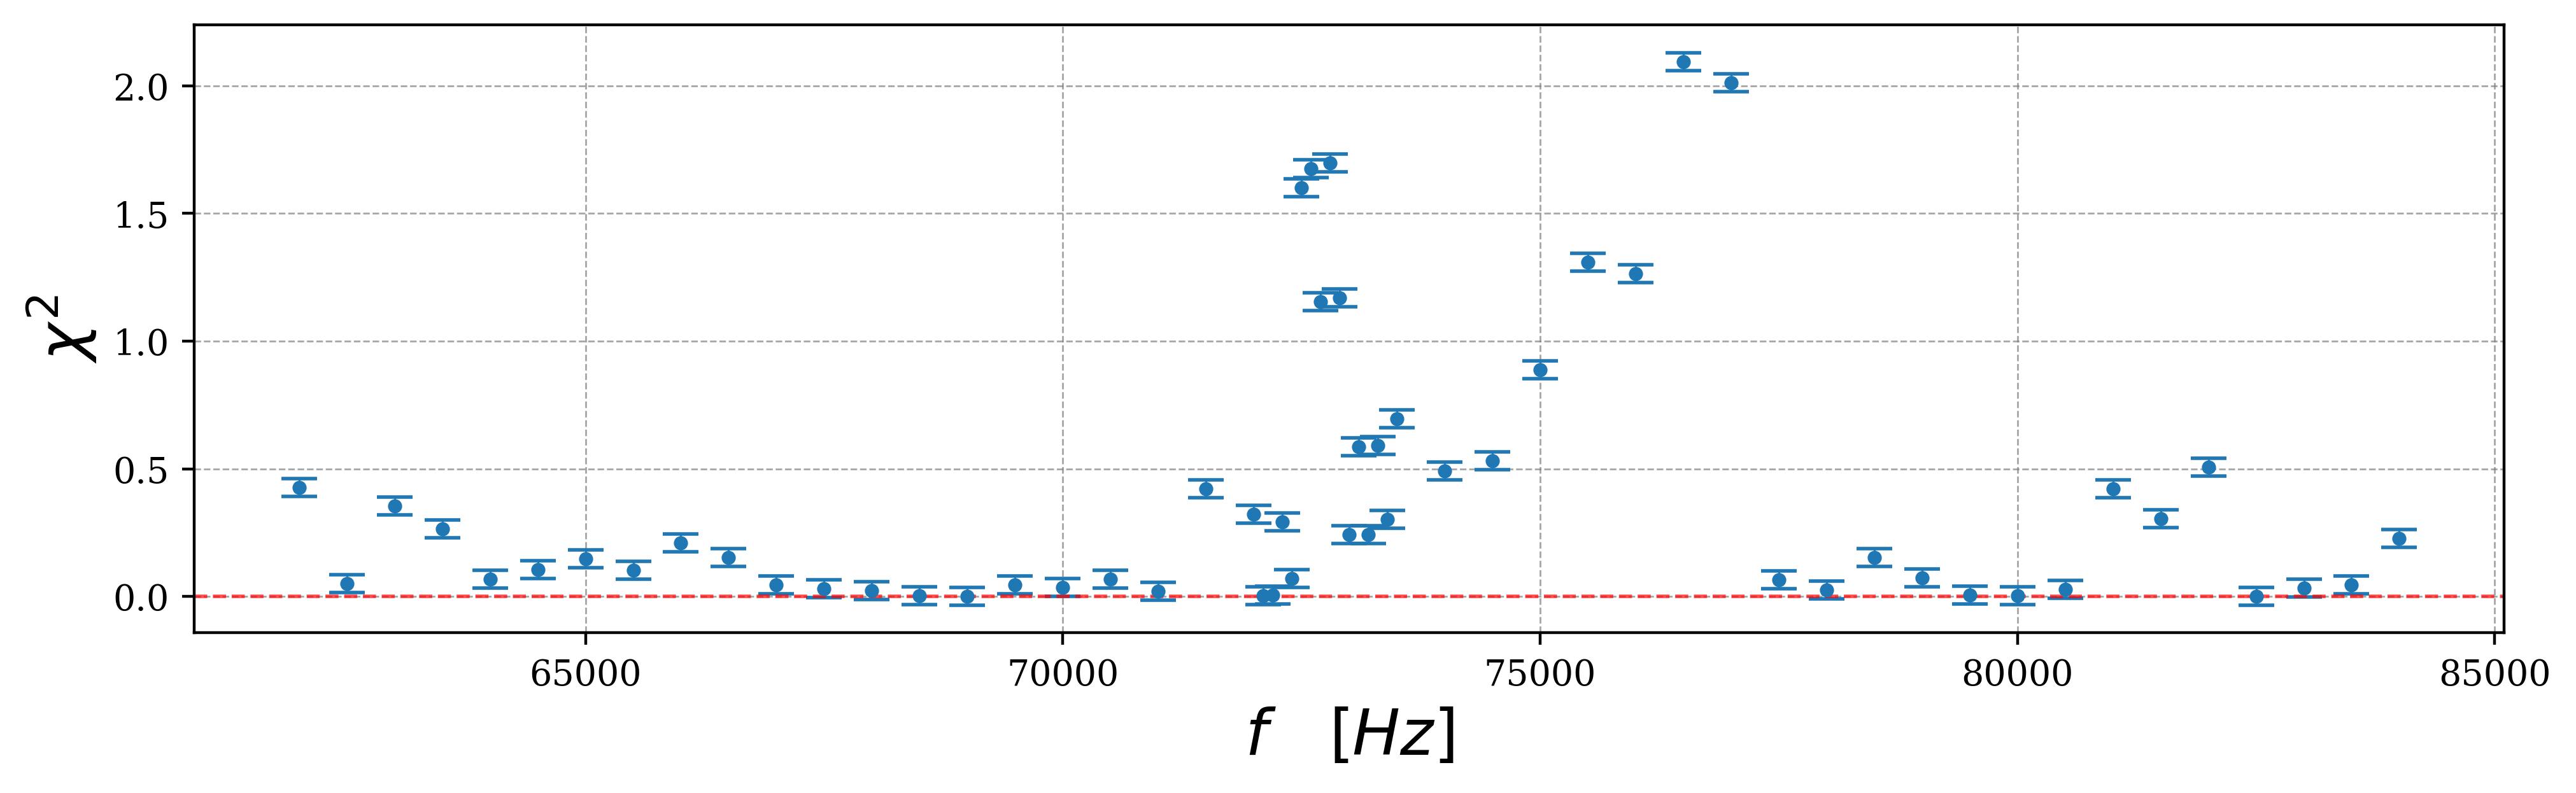

In [47]:
analisi, fig = analizza("sfasamento", modello, param_labels, beta0, legenda_bbox = (1,0), legenda_loc="lower right", legenda_fontsize = 10, ritorno_grafico = True)

In [48]:
print(analisi)

Parametri regressione :
440260.7046214996 ± 4.306752102622848
6.464119186689064 ± 0.08254324710213214
-2742.2243339680067 ± 22.006409376737757
-0.006419881620709576 ± 0.008500854308531001

Somma residui :
0.0000
Somma chi quadri e chi ridotto :
23.7082
0.4473



In [49]:
par = analisi.anal[0]
spar = analisi.anal[1]

parametri_profilazione = [[par[0], par[1]], [spar[0], spar[1]]]
parametri_offset = [par[2], par[3]]
parametri = [parametri_profilazione, parametri_offset]
let.esporta_pickle(parametri, "sfasamento.pkl")

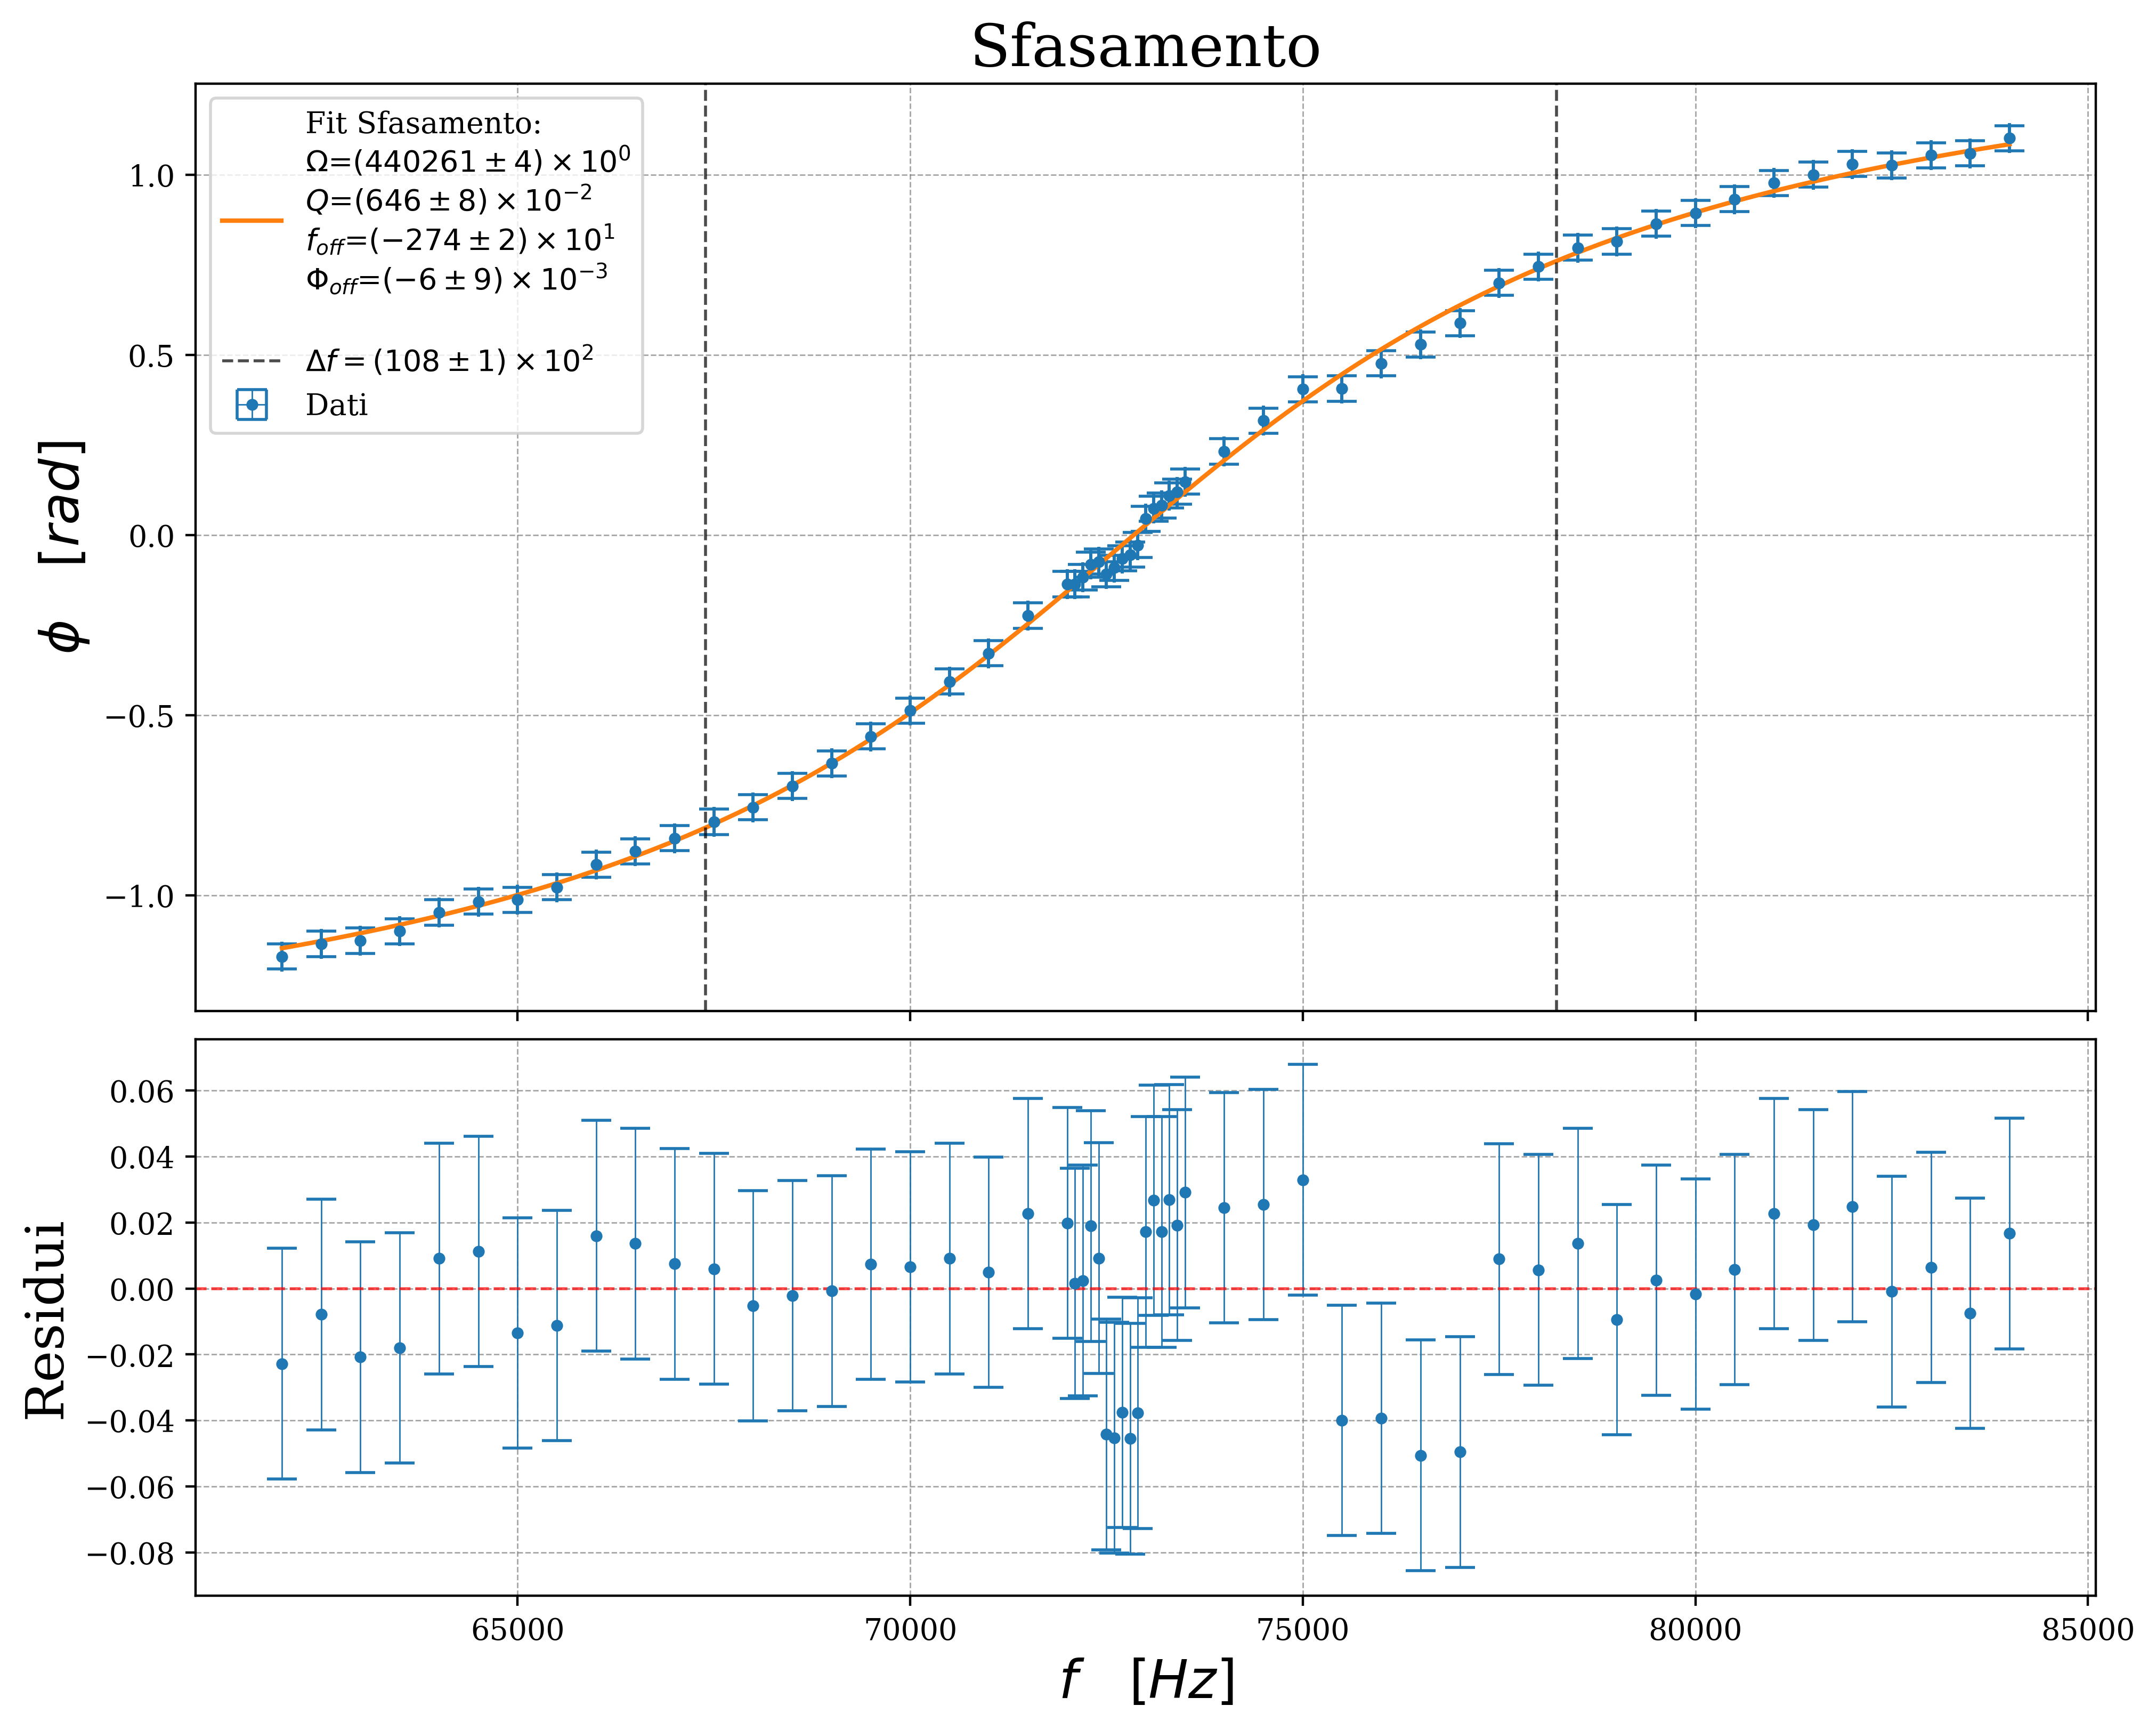

In [50]:
delta = par[0] / (2*par[1])
sdelta = delta * np.sqrt( (spar[0]/par[0])**2 + (spar[1]/par[1])**2)
f0 = par[0] / (2*np.pi) - par[2]

# Larghezza di banda in Hz
bandwidth = abs(( 2 * delta ) / (2 * np.pi))

(ax1, ax2) = fig.axes

ax1.axvline(
    f0 + bandwidth/2,
    **gf.line_params,
    color="black",
    ls="--"
)
ax1.axvline(
    f0 - bandwidth/2,
    **gf.line_params,
    color="black",
    ls="--",
    label=f"$\\Delta f = {gf.formatta_errore(bandwidth,( 2 * sdelta ) /(2*np.pi))}$"
)

ax1.legend(fontsize=10)

let.salva_grafico(fig,"sfasamento/regressione.pdf")

fig